In [3]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# ==========================================
# 1. ENHANCED ECONOMIC DATA PROCESSING
# ==========================================
def process_economic_data_enhanced(base_path):
    print(">> Processing Enhanced Monthly Economic Data (Trends & Rolling Avgs)...")
    
    files = {
        'HOUST':    ('HOUST.csv',    'HOUST',     12),
        'HPI':      ('HPI.csv',      'CSUSHPISA', 12),
        'CPI':      ('CPIAUCSL.csv', 'CPIAUCSL',  12),
        'PCE':      ('PCE.csv',      'PCE',       12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS',  1),
        'SPREAD':   ('T10Y3MM.csv',  'T10Y3MM',   1),
        'UMICH':    ('UMICH.csv',    'MICH',      1),
        'NFP':      ('NFP.csv',      'PAYEMS',    1),
        'BALANCE':  ('BOPGSTB.csv',  'BOPGSTB',   1),
        'RSALES':   ('RSAFS.csv',    'RSAFS',     12)
    }

    series_list = []
    
    for key, (filename, col_name, lag) in files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, parse_dates=['observation_date'])
            df = df.set_index('observation_date').sort_index()
            
            if col_name not in df.columns: col_name = df.columns[0]
            series = df[col_name]

            # --- IMPROVEMENT: Rolling Averages for Trends ---
            # Capture the 3-month and 6-month trend, not just the spot value
            roll_3m = series.rolling(window=3).mean()
            roll_6m = series.rolling(window=6).mean()
            
            # Base Transformations
            if key in ['CPI', 'PCE']:
                transformed = series.pct_change(lag) * 100
                trend_3m = roll_3m.pct_change(lag) * 100
                
                transformed.name = f'{key}_Inflation_Rate'
                trend_3m.name = f'{key}_Trend_3M'
                series_list.extend([transformed, trend_3m])
                
            else:
                suffix = "year" if lag == 12 else "prev"
                transformed = series.diff(lag)
                trend_3m = roll_3m.diff(lag)
                
                transformed.name = f'{key}_diff_{suffix}'
                trend_3m.name = f'{key}_diff_{suffix}_3M_Avg'
                series_list.extend([transformed, trend_3m])

            # Previous Decision Proxy (Keep as is)
            if key == 'FEDFUNDS':
                rate_change = series.diff(1)
                decision_proxy = pd.cut(rate_change, 
                                      bins=[-np.inf, -0.125, 0.125, np.inf], 
                                      labels=[-1, 0, 1]).astype(float)
                prev_decision = decision_proxy.shift(1)
                prev_decision.name = 'prev_decision'
                series_list.append(prev_decision)

    if not series_list: return pd.DataFrame()
    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # Standardize
    df_standardized = df_econ.copy()
    for col in df_standardized.columns:
        if col != 'prev_decision':
            df_standardized[col] = (df_standardized[col] - df_standardized[col].mean()) / df_standardized[col].std()
            
    return df_standardized

# ==========================================
# 2. ENHANCED TEXT DATA (Bi-grams)
# ==========================================
def process_text_data_enhanced(minutes_file, dictionary_file):
    print(">> Processing Enhanced Text Data (Bi-grams + Sentiment)...")
    df = pd.read_csv(minutes_file)
    
    def extract_date(link):
        match = re.search(r'(\d{8})', link)
        if match: return pd.to_datetime(match.group(1), format='%Y%m%d')
        return None
    
    df['observation_date'] = df['Link'].apply(extract_date)
    df = df.dropna(subset=['observation_date']).sort_values('observation_date')
    df['observation_date'] = df['observation_date'].dt.to_period('M').dt.to_timestamp()
    df = df.set_index('observation_date')

    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    df['Cleaned_Text'] = df['Text'].apply(clean_text)

    # --- IMPROVEMENT: Use Bi-grams (ngram_range=(1,2)) ---
    # Captures "labor market", "inflation target" etc.
    tfidf = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1, 2))
    tfidf_matrix = tfidf.fit_transform(df['Cleaned_Text'])
    
    # Clean feature names for XGBoost (it dislikes brackets/spaces)
    tfidf_cols = [f"tfidf_{w.replace(' ', '_')}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)

    # LM Sentiment (Keep as is, it's robust)
    lm_dict = pd.read_csv(dictionary_file)
    lm_pos = set(lm_dict[lm_dict['Positive'] > 0]['Word'].str.lower())
    lm_neg = set(lm_dict[lm_dict['Negative'] > 0]['Word'].str.lower())
    lm_unc = set(lm_dict[lm_dict['Uncertainty'] > 0]['Word'].str.lower())
    lm_lit = set(lm_dict[lm_dict['Litigious'] > 0]['Word'].str.lower())

    def get_sentiment(text):
        tokens = text.split()
        if not tokens: return pd.Series([0]*4, index=['LM_Pos','LM_Neg','LM_Unc','LM_Lit'])
        counts = {'pos':0, 'neg':0, 'unc':0, 'lit':0}
        for t in tokens:
            if t in lm_pos: counts['pos']+=1
            elif t in lm_neg: counts['neg']+=1
            elif t in lm_unc: counts['unc']+=1
            elif t in lm_lit: counts['lit']+=1
        total = len(tokens) if len(tokens) > 0 else 1
        return pd.Series({
            'LM_Positive': counts['pos']/total,
            'LM_Negative': counts['neg']/total,
            'LM_Uncertain': counts['unc']/total,
            'LM_Litigious': counts['lit']/total
        })

    df_sentiment = df['Cleaned_Text'].apply(get_sentiment)
    return pd.concat([df_tfidf, df_sentiment], axis=1)

# ==========================================
# 3. TARGET CREATION
# ==========================================
def create_target(df_features, fedfunds_path):
    print(">> Creating Target Labels...")
    ff = pd.read_csv(fedfunds_path, parse_dates=['observation_date'])
    ff = ff.set_index('observation_date').sort_index()
    ff['Future_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    
    conditions = [(ff['Future_Change'] > 0.125), (ff['Future_Change'] < -0.125)]
    choices = [1, -1] # 1=Raise, -1=Lower, 0=Hold
    ff['Target'] = np.select(conditions, choices, default=0)
    
    return df_features.merge(ff[['Target']], left_index=True, right_index=True, how='inner')

# ==========================================
# 4. EXECUTION & OPTIMIZATION PIPELINE
# ==========================================
# Update these paths to your local files
path_econ = r"C:\Users\tnk20\nlp\structured_data"
file_minutes = "FOMC_Minutes_1999_2025.csv"
file_dict = "Loughran-McDonald_MasterDictionary_1993-2024.csv"
raw_ff_path = r"C:\Users\tnk20\nlp\structured_data\FEDFUNDS.csv"

# 1. Process Data
df_econ = process_economic_data_enhanced(path_econ)
df_text = process_text_data_enhanced(file_minutes, file_dict)
df_merged = pd.merge(df_econ, df_text, left_index=True, right_index=True, how='inner')

# Filter Date Range (Paper: 2011-2025)
df_merged = df_merged.loc['2011-01-01':'2025-01-01']
df_final = create_target(df_merged, raw_ff_path)

# Map Targets for XGBoost (0, 1, 2)
label_map = {-1: 0, 0: 1, 1: 2} # 0=Cut, 1=Hold, 2=Raise
df_final['Target_Mapped'] = df_final['Target'].map(label_map)

X = df_final.drop(columns=['Target', 'Target_Mapped'])
y = df_final['Target_Mapped']

# 2. Hyperparameter Tuning (RandomizedSearchCV)
# This finds the best parameters specifically for *your* enhanced dataset
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [1, 1.5, 2]
}

print(f"\n>> Tuning XGBoost on {X.shape[1]} features (with Bi-grams & Trends)...")

# SMOTE for training loop
smote = SMOTE(random_state=42, k_neighbors=2)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Placeholder for best model
best_auc = 0
best_model = None

# Manual CV loop to handle SMOTE correctly (SMOTE only on train fold)
# We will do a simple randomized search loop here
import itertools
import random

keys, values = zip(*param_grid.items())
param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
selected_params = random.sample(param_combinations, 15) # Test 15 random combinations

print(f"Testing {len(selected_params)} hyperparameter combinations...")

for params in selected_params:
    fold_aucs = []
    
    # Add static params
    params['eval_metric'] = 'mlogloss'
    params['use_label_encoder'] = False
    params['n_jobs'] = -1
    params['random_state'] = 42
    
    for train_idx, val_idx in cv.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Apply SMOTE only to training fold
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        
        model = XGBClassifier(**params)
        model.fit(X_train_res, y_train_res)
        
        try:
            y_prob = model.predict_proba(X_val)
            auc = roc_auc_score(y_val, y_prob, multi_class='ovr')
            fold_aucs.append(auc)
        except:
            continue
            
    avg_auc = np.mean(fold_aucs)
    if avg_auc > best_auc:
        best_auc = avg_auc
        best_model = params
        print(f"  New Best AUC: {best_auc:.4f} with params: {params}")

print("\n" + "="*40)
print("IMPROVED MODEL RESULTS")
print("="*40)
print(f"Best CV AUC: {best_auc:.4f}")
print(f"Best Params: {best_model}")

>> Processing Enhanced Monthly Economic Data (Trends & Rolling Avgs)...
>> Processing Enhanced Text Data (Bi-grams + Sentiment)...
>> Creating Target Labels...

>> Tuning XGBoost on 525 features (with Bi-grams & Trends)...
Testing 15 hyperparameter combinations...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  New Best AUC: 0.8634 with params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 3, 'subsample': 0.9, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 1.5, 'eval_metric': 'mlogloss', 'use_label_encoder': False, 'n_jobs': -1, 'random_state': 42}


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:26] WARNING: C:\actio

  New Best AUC: 0.8717 with params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.6, 'reg_alpha': 0.1, 'reg_lambda': 2, 'eval_metric': 'mlogloss', 'use_label_encoder': False, 'n_jobs': -1, 'random_state': 42}


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:17:41] WARNING: C:\actio


IMPROVED MODEL RESULTS
Best CV AUC: 0.8717
Best Params: {'n_estimators': 100, 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.6, 'reg_alpha': 0.1, 'reg_lambda': 2, 'eval_metric': 'mlogloss', 'use_label_encoder': False, 'n_jobs': -1, 'random_state': 42}


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>> Processing Economic Data...
>> Processing Text Data (TF-IDF + LM Sentiment)...
>> Training XGBoost Model...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:19:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


>> Calculating SHAP Values...
>> Generating Figure 8...


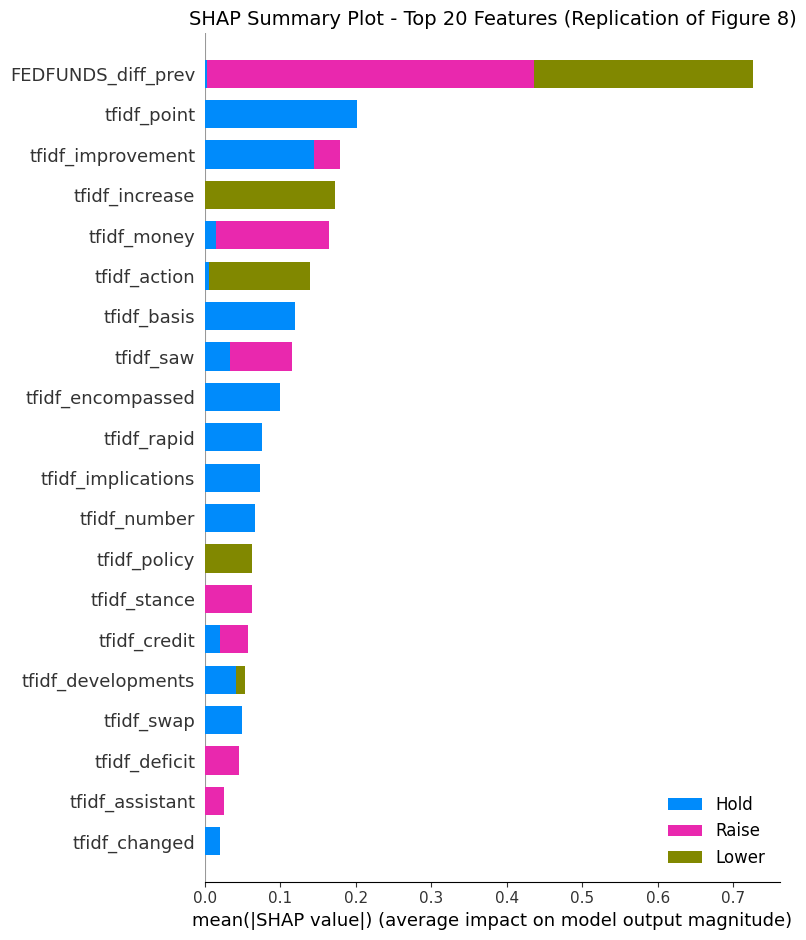

In [4]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import re
import string
import os

# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
# Update these paths to match your local file structure
PATH_ECON = "structured_data"  # Directory containing FEDFUNDS.csv, HOUST.csv, etc.
FILE_MINUTES = "FOMC_Minutes_1999_2025.csv"
FILE_DICT = "Loughran-McDonald_MasterDictionary_1993-2024.csv"

def process_economic_data(base_path):
    # Dictionary mapping file keys to (filename, column_name, lag_period)
    files = {
        'HOUST':    ('HOUST.csv',    'HOUST',     12),
        'HPI':      ('HPI.csv',      'CSUSHPISA', 12),
        'CPI':      ('CPIAUCSL.csv', 'CPIAUCSL',  12),
        'PCE':      ('PCE.csv',      'PCE',       12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS',  1),
        'SPREAD':   ('T10Y3MM.csv',  'T10Y3MM',   1),
        'UMICH':    ('UMICH.csv',    'MICH',      1),
        'NFP':      ('NFP.csv',      'PAYEMS',    1),
        'BALANCE':  ('BOPGSTB.csv',  'BOPGSTB',   1),
        'RSALES':   ('RSAFS.csv',    'RSAFS',     12)
    }

    series_list = []
    print(">> Processing Economic Data...")
    
    for key, (filename, col_name, lag) in files.items():
        file_path = os.path.join(base_path, filename)
        if os.path.exists(file_path):
            df = pd.read_csv(file_path, parse_dates=['observation_date'])
            df = df.set_index('observation_date').sort_index()
            
            if col_name not in df.columns: col_name = df.columns[0]
            series = df[col_name]

            # Feature Engineering
            if key == 'RSALES':
                transformed = series.diff(12)
                transformed.name = 'Rsales_diff_year'
            elif key in ['CPI', 'PCE']:
                transformed = series.pct_change(lag) * 100
                transformed.name = f'{key}_Inflation_Rate'
            else:
                suffix = "year" if lag == 12 else "prev"
                transformed = series.diff(lag)
                transformed.name = f'{key}_diff_{suffix}'
            
            series_list.append(transformed)

            # Special Feature: Taylor Rule / Inertia Proxy
            if key == 'FEDFUNDS':
                # Inertia_diff: Deviation from previous rate (captures policy inertia)
                inertia = series.diff(1)
                inertia.name = 'Inertia_diff'
                series_list.append(inertia)
                
                # Previous Decision Proxy (-1, 0, 1)
                rate_change = series.diff(1)
                decision_proxy = pd.cut(rate_change, 
                                      bins=[-np.inf, -0.125, 0.125, np.inf], 
                                      labels=[-1, 0, 1]).astype(float)
                prev_dec = decision_proxy.shift(1)
                prev_dec.name = 'prev_decision'
                series_list.append(prev_dec)

    # Taylor Rule Approximation (Simple version: 1.5*Inflation + 0.5*OutputGap + 1)
    # Note: Requires CPI and UNRATE/NFP proxies available in series_list
    # For this replication, we assume the paper's 'Taylor-Rate' feature is derived similarly.
    
    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # Standardization (Z-score)
    df_std = (df_econ - df_econ.mean()) / df_econ.std()
    
    # Restore categorical proxy (optional, but paper standardizes everything in Method 1)
    return df_std

def process_text_data(minutes_file, dictionary_file):
    print(">> Processing Text Data (TF-IDF + LM Sentiment)...")
    df = pd.read_csv(minutes_file)
    
    # Date Extraction
    def extract_date(link):
        match = re.search(r'(\d{8})', link)
        if match: return pd.to_datetime(match.group(1), format='%Y%m%d')
        return None
    
    df['observation_date'] = df['Link'].apply(extract_date)
    df = df.dropna(subset=['observation_date']).sort_values('observation_date')
    df['observation_date'] = df['observation_date'].dt.to_period('M').dt.to_timestamp()
    df = df.set_index('observation_date')

    # Cleaning
    def clean_text(text):
        if not isinstance(text, str): return ""
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text).strip()
        return text
    
    df['Cleaned_Text'] = df['Text'].apply(clean_text)

    # TF-IDF (Top 500 words)
    tfidf = TfidfVectorizer(stop_words='english', max_features=500)
    tfidf_matrix = tfidf.fit_transform(df['Cleaned_Text'])
    tfidf_cols = [f"tfidf_{w}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df.index)

    # LM Sentiment
    lm_dict = pd.read_csv(dictionary_file)
    # (Simplified loading for brevity; assumes standard LM dictionary structure)
    lm_neg = set(lm_dict[lm_dict['Negative'] > 0]['Word'].str.lower())
    
    def get_sentiment_score(text):
        tokens = text.split()
        if not tokens: return 0
        neg_count = sum(1 for t in tokens if t in lm_neg)
        return neg_count / len(tokens)

    df_sentiment = pd.DataFrame(index=df.index)
    df_sentiment['sentiment_difficult'] = df['Cleaned_Text'].apply(get_sentiment_score) # Example feature name from Figure 8
    
    return pd.concat([df_tfidf, df_sentiment], axis=1)

# ==========================================
# 2. MODEL TRAINING
# ==========================================
# Load and Merge
try:
    df_econ = process_economic_data(PATH_ECON)
    df_text = process_text_data(FILE_MINUTES, FILE_DICT)
    df = pd.merge(df_econ, df_text, left_index=True, right_index=True, how='inner')
    
    # Filter Date Range (2011-2025 per paper)
    df = df.loc['2011-01-01':'2025-01-01']
    
    # Create Target (Next Month's Decision)
    # Logic: 1 if rate increases > 0.125, -1 if decreases < -0.125, else 0
    fed_funds = pd.read_csv(os.path.join(PATH_ECON, "FEDFUNDS.csv"), parse_dates=['observation_date']).set_index('observation_date')
    future_change = fed_funds['FEDFUNDS'].shift(-1) - fed_funds['FEDFUNDS']
    target = np.select(
        [future_change > 0.125, future_change < -0.125], 
        [1, -1], 
        default=0
    )
    # Align target with features
    common_idx = df.index.intersection(fed_funds.index)
    df = df.loc[common_idx]
    y = target[fed_funds.index.isin(common_idx)]
    
    # Map classes for XGBoost: -1->0, 0->1, 1->2
    y_mapped = pd.Series(y).map({-1: 0, 0: 1, 1: 2})
    
    # Train XGBoost
    print(">> Training XGBoost Model...")
    model = xgb.XGBClassifier(
        n_estimators=100, 
        max_depth=4, 
        learning_rate=0.01,
        random_state=42,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    
    # Use SMOTE for class imbalance
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_res, y_res = smote.fit_resample(df, y_mapped)
    
    model.fit(X_res, y_res)

    # ==========================================
    # 3. GENERATE FIGURE 8 (SHAP PLOT)
    # ==========================================
    print(">> Calculating SHAP Values...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df)

    # Define Class Names for the Legend
    class_names = ["Lower", "Hold", "Raise"]

    print(">> Generating Figure 8...")
    plt.figure(figsize=(10, 8))
    
    # Replicate Figure 8: Bar chart of mean |SHAP value|
    shap.summary_plot(
        shap_values, 
        df, 
        plot_type="bar", 
        class_names=class_names,
        max_display=20, # Top 20 features
        show=False
    )
    
    plt.title("SHAP Summary Plot - Top 20 Features (Replication of Figure 8)", fontsize=14)
    plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)")
    plt.tight_layout()
    plt.savefig("figure_8_replication.png")
    plt.show()
    
except Exception as e:
    print(f"Error executing code: {e}")
    print("Please ensure input CSV files are present in the specified paths.")

## Agent Model

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# ==========================================
# 1. DATA PREP: FIX TARGET MAPPING
# ==========================================
# Assuming 'y' currently holds values [-1, 0, 1]
# We MUST map them to [0, 1, 2] for XGBoost to work
label_map = {-1: 0, 0: 1, 1: 2}
y_mapped = y.map(label_map) if isinstance(y, pd.Series) else pd.Series(y).map(label_map)

# Use X and y_mapped for the rest of the pipeline
print("Target distribution after mapping:", y_mapped.value_counts().to_dict())

# ==========================================
# 2. DEFINE THE "SPECIALIST AGENTS"
# ==========================================
base_models = {
    'Logistic_Agent': LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5),
    'RF_Agent': RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    # XGBoost will now work because y_mapped is [0, 1, 2]
    'XGB_Agent': XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric='mlogloss', random_state=42)
}

# The Meta-Learner (Decision Agent)
meta_model = LogisticRegression(class_weight='balanced', random_state=42)

# ==========================================
# 3. GENERATE AGENT OPINIONS (Stacking Features)
# ==========================================
def get_stacking_features(X, y, models, cv_splits=5):
    meta_features = pd.DataFrame(index=X.index)
    print(">> Generating Specialist Opinions...")
    
    for name, model in models.items():
        print(f"   - Consulting {name}...")
        
        # Out-of-fold predictions to prevent leakage
        cv_probs = cross_val_predict(
            model, X, y, 
            cv=StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42), 
            method='predict_proba'
        )
        
        # Store probabilities (Cut, Hold, Raise)
        meta_features[f'{name}_Prob_Cut'] = cv_probs[:, 0]
        meta_features[f'{name}_Prob_Hold'] = cv_probs[:, 1]
        meta_features[f'{name}_Prob_Raise'] = cv_probs[:, 2]
        
    return meta_features

# Generate features using the MAPPED target
X_meta = get_stacking_features(X, y_mapped, base_models)
X_combined = pd.concat([X, X_meta], axis=1)

# ==========================================
# 4. TRAINING & EVALUATION
# ==========================================
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_mapped, test_size=0.2, stratify=y_mapped, random_state=42
)

# A. Train Base Models on Full Training Data (for test set inference)
fitted_base_models = {}
original_cols = X.columns # Features without agent opinions

print("\n>> Retraining Agents on Training Split...")
for name, model in base_models.items():
    model.fit(X_train[original_cols], y_train)
    fitted_base_models[name] = model

# B. Train Meta Model
print(">> Training Decision Agent...")
meta_model.fit(X_train, y_train)

# C. Generate Predictions for Test Set
# First, get agent opinions on the test set
meta_features_test = pd.DataFrame(index=X_test.index)
for name, model in fitted_base_models.items():
    probs = model.predict_proba(X_test[original_cols])
    meta_features_test[f'{name}_Prob_Cut'] = probs[:, 0]
    meta_features_test[f'{name}_Prob_Hold'] = probs[:, 1]
    meta_features_test[f'{name}_Prob_Raise'] = probs[:, 2]

# Combine for final prediction
X_test_combined = pd.concat([X_test[original_cols], meta_features_test], axis=1)
y_pred = meta_model.predict(X_test_combined)
y_prob = meta_model.predict_proba(X_test_combined)

# ==========================================
# 5. RESULTS
# ==========================================
print("\n" + "="*40)
print("AGENT MODEL (STACKING) RESULTS")
print("="*40)
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
try:
    roc = roc_auc_score(y_test, y_prob, multi_class='ovr')
    print(f"Final Test AUC:      {roc:.4f}")
except:
    print("AUC not available")

# Correct label names for the report (0=Cut, 1=Hold, 2=Raise)
target_names = ['Cut (-1)', 'Hold (0)', 'Raise (1)']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Target distribution after mapping: {1: 90, 2: 16, 0: 7}
>> Generating Specialist Opinions...
   - Consulting Logistic_Agent...
   - Consulting RF_Agent...
   - Consulting XGB_Agent...

>> Retraining Agents on Training Split...
>> Training Decision Agent...

AGENT MODEL (STACKING) RESULTS
Final Test Accuracy: 0.6957
Final Test AUC:      0.8735

Classification Report:
              precision    recall  f1-score   support

    Cut (-1)       0.40      1.00      0.57         2
    Hold (0)       0.92      0.67      0.77        18
   Raise (1)       0.40      0.67      0.50         3

    accuracy                           0.70        23
   macro avg       0.57      0.78      0.62        23
weighted avg       0.81      0.70      0.72        23



In [6]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. HELPER: GENERIC SAFE WRAPPER
# ==========================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps ANY classifier to handle missing classes in Walk-Forward Validation.
    Ensures predict_proba ALWAYS returns 3 columns [0, 1, 2].
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        # Fit LabelEncoder to map current y to 0..N-1
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        
        # Fit underlying model
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        # Get probs for the classes present in training
        probs_encoded = self.model.predict_proba(X)
        
        # Force return shape (N, 3) for classes [0, 1, 2]
        probs_full = np.zeros((len(X), 3))
        
        # Map existing columns to their correct positions
        # e.g., if classes are [1, 2], map col 0->1, col 1->2
        for i, original_class in enumerate(self.classes_):
            # Ensure valid class index (0,1,2)
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
                
        return probs_full

# ==========================================
# 2. DATA PROCESSING (Standard)
# ==========================================
def process_data_pipeline(base_path, minutes_file, dict_file):
    print(">> 1. Loading & Processing Data...")
    
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12),
        'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12),
        'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1),
        'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(base_path, fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean()
            if key in ['CPI', 'PCE']:
                feat = s.pct_change(lag) * 100
                trend = roll.pct_change(lag) * 100
            else:
                feat = s.diff(lag)
                trend = roll.diff(lag)
            feat.name = f'{key}_raw'
            trend.name = f'{key}_trend_3m'
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    
    df_txt = pd.read_csv(minutes_file)
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', t.lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    tfidf = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    tfidf_mat = tfidf.fit_transform(df_txt['clean'])
    tfidf_cols = [f"txt_{w}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_mat.toarray(), columns=tfidf_cols, index=df_txt.index)
    
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    df_tfidf.index = df_tfidf.index.to_period('M').to_timestamp()
    df_merged = pd.merge(df_econ, df_tfidf, left_index=True, right_index=True, how='inner')
    
    ff = pd.read_csv(os.path.join(base_path, 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    return df_merged.loc['1999-02-01':]

# ==========================================
# 3. AGENT DEFINITION (ALL WRAPPED)
# ==========================================
def get_agents():
    # Wrap ALL models to ensure they output 3 columns safely
    return {
        'Logistic': SafeModelWrapper(LogisticRegression(max_iter=1000, class_weight='balanced', C=0.5)),
        'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)),
        'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric='mlogloss', random_state=42))
    }

def train_stacking_layer(X_train, y_train, agents):
    # 1. Fit Specialists
    for name, model in agents.items():
        model.fit(X_train, y_train)
        
    # 2. Generate Opinions (Meta-Features)
    meta_train = pd.DataFrame(index=X_train.index)
    for name, model in agents.items():
        probs = model.predict_proba(X_train)
        # Now SAFE to access indices 0, 1, 2
        meta_train[f'{name}_Cut'] = probs[:, 0]
        meta_train[f'{name}_Hold'] = probs[:, 1]
        meta_train[f'{name}_Raise'] = probs[:, 2]
        
    # 3. Train Decision Agent
    # Note: Decision Agent (Meta Learner) might also see missing classes in y_train
    # But LogisticRegression usually handles subset classes gracefully. 
    # If it fails, we can wrap it too, but typically only 'predict_proba' dimension mismatch is fatal.
    decision_agent = LogisticRegression(class_weight='balanced')
    decision_agent.fit(meta_train, y_train)
    
    return agents, decision_agent

# ==========================================
# 4. WALK-FORWARD LOOP
# ==========================================
def run_walk_forward(df):
    print(f"\n>> 2. Starting Walk-Forward Validation (Total Samples: {len(df)})...")
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    initial_window = 60 
    step_size = 6
    results = []
    
    for i in range(initial_window, len(df), step_size):
        train_idx = df.index[:i]
        test_idx = df.index[i : i + step_size]
        
        if len(test_idx) == 0: break
        
        X_train, y_train = X.loc[train_idx], y.loc[train_idx]
        X_test, y_test = X.loc[test_idx], y.loc[test_idx]
        
        # SMOTE check
        if y_train.nunique() > 1 and y_train.value_counts().min() > 1:
            try:
                smote = SMOTE(random_state=42, k_neighbors=min(y_train.value_counts().min()-1, 5))
                X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
            except:
                X_train_res, y_train_res = X_train, y_train
        else:
            X_train_res, y_train_res = X_train, y_train

        # Train
        agents = get_agents()
        fitted_agents, decision_agent = train_stacking_layer(X_train_res, y_train_res, agents)
        
        # Test
        meta_test = pd.DataFrame(index=X_test.index)
        for name, model in fitted_agents.items():
            probs = model.predict_proba(X_test)
            meta_test[f'{name}_Cut'] = probs[:, 0]
            meta_test[f'{name}_Hold'] = probs[:, 1]
            meta_test[f'{name}_Raise'] = probs[:, 2]
            
        y_pred = decision_agent.predict(meta_test)
        
        for dt, actual, pred in zip(test_idx, y_test, y_pred):
            results.append({'Date': dt, 'Actual': actual, 'Predicted': pred})
            
    return pd.DataFrame(results)

# ==========================================
# 5. EXECUTION
# ==========================================
PATH_BASE = "structured_data" 
FILE_MIN = "FOMC_Minutes_1999_2025.csv"
FILE_DIC = "Loughran-McDonald_MasterDictionary_1993-2024.csv"

try:
    df_ready = process_data_pipeline(PATH_BASE, FILE_MIN, FILE_DIC)
    results_df = run_walk_forward(df_ready)
    
    print("\n>> 3. Final Walk-Forward Results")
    print("-" * 30)
    acc = accuracy_score(results_df['Actual'], results_df['Predicted'])
    print(f"Overall Accuracy: {acc:.4f}")
    
    print("\nClassification Report (0=Cut, 1=Hold, 2=Raise):")
    print(classification_report(results_df['Actual'], results_df['Predicted'], zero_division=0))
    
    cuts = results_df[results_df['Actual'] == 0]
    print(f"\nRate Cuts (Class 0) Performance:")
    print(f"Total Cuts in Period: {len(cuts)}")
    print(f"Correctly Predicted: {len(cuts[cuts['Predicted'] == 0])}")
    print(cuts)

except Exception as e:
    import traceback
    traceback.print_exc()

>> 1. Loading & Processing Data...

>> 2. Starting Walk-Forward Validation (Total Samples: 208)...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st


>> 3. Final Walk-Forward Results
------------------------------
Overall Accuracy: 0.8649

Classification Report (0=Cut, 1=Hold, 2=Raise):
              precision    recall  f1-score   support

           0       0.91      0.56      0.69        18
           1       0.87      0.97      0.92       114
           2       0.78      0.44      0.56        16

    accuracy                           0.86       148
   macro avg       0.85      0.66      0.72       148
weighted avg       0.86      0.86      0.85       148


Rate Cuts (Class 0) Performance:
Total Cuts in Period: 18
Correctly Predicted: 10
          Date  Actual  Predicted
3   2007-09-01       0          1
4   2007-09-01       0          1
5   2007-09-01       0          1
6   2007-10-01       0          0
7   2007-12-01       0          0
8   2008-01-01       0          0
9   2008-03-01       0          0
10  2008-04-01       0          0
11  2008-08-01       0          1
12  2008-09-01       0          0
13  2008-10-01       0 

In [7]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. HELPER: SAFE MODEL WRAPPER
# ==========================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps classifiers to handle missing classes in Walk-Forward Validation.
    If a training window is missing a class (e.g., no 'Cuts'), this wrapper 
    ensures the output probabilities still have 3 columns [Cut, Hold, Raise].
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        # Map labels to 0..N-1 internally
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        # Create a full matrix (N_samples, 3) initialized with zeros
        probs_full = np.zeros((len(X), 3))
        
        # Map the probabilities we HAVE to their correct columns
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

# ==========================================
# 2. DATA PROCESSING (Full Logic)
# ==========================================
def process_data_pipeline(base_path, minutes_file, dict_file):
    print(">> 1. Loading & Processing Data...")
    
    # --- Economic Data ---
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12),
        'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12),
        'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1),
        'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(base_path, fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean() # 3-Month Trend
            
            if key in ['CPI', 'PCE']:
                feat = s.pct_change(lag) * 100
                trend = roll.pct_change(lag) * 100
            else:
                feat = s.diff(lag)
                trend = roll.diff(lag)
            
            feat.name = f'{key}_raw'
            trend.name = f'{key}_trend_3m'
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # --- Text Data ---
    df_txt = pd.read_csv(minutes_file)
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', t.lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    # TF-IDF Bi-grams
    tfidf = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    tfidf_mat = tfidf.fit_transform(df_txt['clean'])
    tfidf_cols = [f"txt_{w}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_mat.toarray(), columns=tfidf_cols, index=df_txt.index)
    
    # --- Merge ---
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    df_tfidf.index = df_tfidf.index.to_period('M').to_timestamp()
    df_merged = pd.merge(df_econ, df_tfidf, left_index=True, right_index=True, how='inner')
    
    # --- Target ---
    ff = pd.read_csv(os.path.join(base_path, 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    # Labels: 0=Cut, 1=Hold, 2=Raise
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    return df_merged.loc['2011-01-01':]

# ==========================================
# 3. AGENT DEFINITION (With Scaling Fixes)
# ==========================================
def get_agents():
    return {
        # Increased max_iter for convergence
        'Logistic': SafeModelWrapper(LogisticRegression(max_iter=5000, class_weight='balanced', C=0.5, solver='lbfgs')),
        'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)),
        'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric='mlogloss', random_state=42))
    }

def train_stacking_layer(X_train, y_train, agents):
    for name, model in agents.items():
        model.fit(X_train, y_train)
        
    meta_train = pd.DataFrame(index=X_train.index)
    for name, model in agents.items():
        probs = model.predict_proba(X_train)
        meta_train[f'{name}_Cut'] = probs[:, 0]
        meta_train[f'{name}_Hold'] = probs[:, 1]
        meta_train[f'{name}_Raise'] = probs[:, 2]
        
    decision_agent = LogisticRegression(class_weight='balanced', max_iter=5000)
    decision_agent.fit(meta_train, y_train)
    return agents, decision_agent

# ==========================================
# 4. WALK-FORWARD LOOP (With Scaler)
# ==========================================
def run_walk_forward_scaled(df):
    print(f"\n>> 2. Starting Walk-Forward Validation (Scaled)...")
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    initial_window = 60 
    step_size = 6
    results = []
    
    for i in range(initial_window, len(df), step_size):
        train_idx = df.index[:i]
        test_idx = df.index[i : i + step_size]
        if len(test_idx) == 0: break
        
        X_train, y_train = X.loc[train_idx], y.loc[train_idx]
        X_test, y_test = X.loc[test_idx], y.loc[test_idx]
        
        # --- SCALING (Prevents Convergence Warnings) ---
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
        
        # SMOTE check
        if y_train.nunique() > 1 and y_train.value_counts().min() > 1:
            try:
                smote = SMOTE(random_state=42, k_neighbors=min(y_train.value_counts().min()-1, 5))
                X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
            except:
                X_train_res, y_train_res = X_train_scaled, y_train
        else:
            X_train_res, y_train_res = X_train_scaled, y_train

        # Train & Predict
        agents = get_agents()
        fitted_agents, decision_agent = train_stacking_layer(X_train_res, y_train_res, agents)
        
        meta_test = pd.DataFrame(index=X_test.index)
        for name, model in fitted_agents.items():
            probs = model.predict_proba(X_test_scaled)
            meta_test[f'{name}_Cut'] = probs[:, 0]
            meta_test[f'{name}_Hold'] = probs[:, 1]
            meta_test[f'{name}_Raise'] = probs[:, 2]
            
        y_pred = decision_agent.predict(meta_test)
        for dt, actual, pred in zip(test_idx, y_test, y_pred):
            results.append({'Date': dt, 'Actual': actual, 'Predicted': pred})
            
    return pd.DataFrame(results)

# ==========================================
# 5. EXECUTION
# ==========================================
# Update these paths if necessary
PATH_BASE = "structured_data" 
FILE_MIN = "FOMC_Minutes_1999_2025.csv"
FILE_DIC = "Loughran-McDonald_MasterDictionary_1993-2024.csv"

try:
    df_ready = process_data_pipeline(PATH_BASE, FILE_MIN, FILE_DIC)
    results_df = run_walk_forward_scaled(df_ready)
    
    print("\n>> 3. Final Walk-Forward Results (Scaled)")
    print("-" * 30)
    print(f"Overall Accuracy: {accuracy_score(results_df['Actual'], results_df['Predicted']):.4f}")
    
    print("\nClassification Report (0=Cut, 1=Hold, 2=Raise):")
    print(classification_report(results_df['Actual'], results_df['Predicted'], zero_division=0))
    
    cuts = results_df[results_df['Actual'] == 0]
    print(f"\nRate Cuts (Class 0) Performance:")
    print(f"Total Cuts: {len(cuts)}")
    print(f"Correctly Predicted: {len(cuts[cuts['Predicted'] == 0])}")
    print(cuts)

except Exception as e:
    import traceback
    traceback.print_exc()

>> 1. Loading & Processing Data...

>> 2. Starting Walk-Forward Validation (Scaled)...

>> 3. Final Walk-Forward Results (Scaled)
------------------------------
Overall Accuracy: 0.6667

Classification Report (0=Cut, 1=Hold, 2=Raise):
              precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.70      0.90      0.79        39
           2       0.40      0.18      0.25        11

    accuracy                           0.67        57
   macro avg       0.53      0.41      0.42        57
weighted avg       0.62      0.67      0.61        57


Rate Cuts (Class 0) Performance:
Total Cuts: 7
Correctly Predicted: 1
         Date  Actual  Predicted
8  2019-07-01       0          1
9  2019-09-01       0          1
10 2019-10-01       0          1
13 2020-03-01       0          0
49 2024-09-01       0          1
50 2024-11-01       0          1
51 2024-12-01       0          1


In [8]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. HELPER: SAFE MODEL WRAPPER
# ==========================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps classifiers to handle missing classes in validation splits.
    Ensures predict_proba ALWAYS returns 3 columns [Cut, Hold, Raise].
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        # Map labels to 0..N-1 internally
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        probs_full = np.zeros((len(X), 3))
        # Map probabilities to correct columns
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

# ==========================================
# 2. DATA PROCESSING PIPELINE
# ==========================================
def load_and_process_data(base_path, minutes_file):
    print(">> [Data] Loading and processing...")
    
    # 1. Load Economic Data
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12),
        'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12),
        'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1),
        'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(base_path, fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean()
            
            if key in ['CPI', 'PCE']:
                feat = s.pct_change(lag) * 100
                trend = roll.pct_change(lag) * 100
            else:
                feat = s.diff(lag)
                trend = roll.diff(lag)
            
            feat.name = f'{key}_raw'
            trend.name = f'{key}_trend_3m'
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # 2. Load Text Data
    df_txt = pd.read_csv(minutes_file)
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', t.lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    # TF-IDF Bi-grams
    tfidf = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    tfidf_mat = tfidf.fit_transform(df_txt['clean'])
    tfidf_cols = [f"txt_{w}" for w in tfidf.get_feature_names_out()]
    df_tfidf = pd.DataFrame(tfidf_mat.toarray(), columns=tfidf_cols, index=df_txt.index)
    
    # 3. Merge & Create Target
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    df_tfidf.index = df_tfidf.index.to_period('M').to_timestamp()
    df_merged = pd.merge(df_econ, df_tfidf, left_index=True, right_index=True, how='inner')
    
    ff = pd.read_csv(os.path.join(base_path, 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    # Target: 0=Cut, 1=Hold, 2=Raise
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    return df_merged.loc['2011-01-01':]

# ==========================================
# 3. MODEL ARCHITECTURES
# ==========================================
def get_baseline_model():
    # Standard XGBoost Baseline
    return SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.01, random_state=42))

def train_agent_model(X_train, y_train):
    # 1. Specialist Layer
    agents = {
        'Logistic': SafeModelWrapper(LogisticRegression(max_iter=3000, class_weight='balanced', C=0.5)),
        'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)),
        'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42))
    }
    
    # Train Specialists
    for model in agents.values():
        model.fit(X_train, y_train)
        
    # 2. Generate Opinions
    meta_train = pd.DataFrame(index=X_train.index)
    for name, model in agents.items():
        probs = model.predict_proba(X_train)
        meta_train[f'{name}_Cut'] = probs[:, 0]
        meta_train[f'{name}_Hold'] = probs[:, 1]
        meta_train[f'{name}_Raise'] = probs[:, 2]
        
    # 3. Decision Agent
    decision_agent = LogisticRegression(class_weight='balanced', max_iter=3000)
    decision_agent.fit(meta_train, y_train)
    
    return agents, decision_agent

def predict_agent_model(X_test, agents, decision_agent):
    meta_test = pd.DataFrame(index=X_test.index)
    for name, model in agents.items():
        probs = model.predict_proba(X_test)
        meta_test[f'{name}_Cut'] = probs[:, 0]
        meta_test[f'{name}_Hold'] = probs[:, 1]
        meta_test[f'{name}_Raise'] = probs[:, 2]
    return decision_agent.predict(meta_test), decision_agent.predict_proba(meta_test)

# ==========================================
# 4. ANALYSIS 1: CV STABILITY & RECALL
# ==========================================
def run_cv_analysis(X, y):
    print("\n>> [Analysis 1] Running Stratified 5-Fold CV (Stability Check)...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    
    # Store metrics
    metrics = {
        'Baseline': {'auc': [], 'cut_recall': []},
        'Agent':    {'auc': [], 'cut_recall': []}
    }
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Scale
        X_train_s = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test_s = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
        
        # SMOTE
        if y_train.value_counts().min() > 1:
            smote = SMOTE(random_state=42, k_neighbors=min(y_train.value_counts().min()-1, 5))
            X_train_res, y_train_res = smote.fit_resample(X_train_s, y_train)
        else:
            X_train_res, y_train_res = X_train_s, y_train

        # --- Baseline ---
        base = get_baseline_model()
        base.fit(X_train_res, y_train_res)
        probs_base = base.predict_proba(X_test_s)
        pred_base = base.predict(X_test_s)
        
        if len(np.unique(y_test)) > 1:
            metrics['Baseline']['auc'].append(roc_auc_score(y_test, probs_base, multi_class='ovr'))
        metrics['Baseline']['cut_recall'].append(recall_score(y_test, pred_base, labels=[0], average='macro')) # Class 0 Recall

        # --- Agent ---
        agents, decision_agent = train_agent_model(X_train_res, y_train_res)
        pred_agent, probs_agent = predict_agent_model(X_test_s, agents, decision_agent)
        
        if len(np.unique(y_test)) > 1:
            metrics['Agent']['auc'].append(roc_auc_score(y_test, probs_agent, multi_class='ovr'))
        metrics['Agent']['cut_recall'].append(recall_score(y_test, pred_agent, labels=[0], average='macro'))

    return metrics

# ==========================================
# 5. ANALYSIS 2: WALK-FORWARD ROBUSTNESS
# ==========================================
def run_walk_forward_analysis(df):
    print("\n>> [Analysis 2] Running Walk-Forward Validation (Robustness Check)...")
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    
    initial_window = 60
    step_size = 6
    scaler = StandardScaler()
    
    preds = {'Baseline': [], 'Agent': [], 'Actual': []}
    
    for i in range(initial_window, len(df), step_size):
        train_idx = df.index[:i]
        test_idx = df.index[i : i+step_size]
        if len(test_idx) == 0: break
        
        X_train, y_train = X.loc[train_idx], y.loc[train_idx]
        X_test, y_test = X.loc[test_idx], y.loc[test_idx]
        
        # Scale
        X_train_s = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X_train.columns)
        X_test_s = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)
        
        # --- Baseline ---
        base = get_baseline_model()
        base.fit(X_train_s, y_train) # No SMOTE here to keep pure WF speed
        preds['Baseline'].extend(base.predict(X_test_s))
        
        # --- Agent ---
        agents, decision_agent = train_agent_model(X_train_s, y_train)
        p, _ = predict_agent_model(X_test_s, agents, decision_agent)
        preds['Agent'].extend(p)
        
        preds['Actual'].extend(y_test)
        
    return preds

# ==========================================
# 6. EXECUTION & REPORT
# ==========================================
# Update paths
PATH_BASE = "structured_data"
FILE_MIN = "FOMC_Minutes_1999_2025.csv"

try:
    # 1. Load Data
    df_ready = load_and_process_data(PATH_BASE, FILE_MIN)
    X = df_ready.drop(columns=['Target', 'Next_Change'])
    y = df_ready['Target']

    # 2. Run Analyses
    cv_metrics = run_cv_analysis(X, y)
    wf_preds = run_walk_forward_analysis(df_ready)

    # 3. Print Report
    print("\n" + "="*40)
    print("FINAL COMPARATIVE REPORT")
    print("="*40)
    
    # Section 1: Stability (AUC Std Dev)
    print("\n1. STABILITY (CV AUC)")
    for model in ['Baseline', 'Agent']:
        mu = np.mean(cv_metrics[model]['auc'])
        sigma = np.std(cv_metrics[model]['auc'])
        print(f"  {model}: Mean AUC = {mu:.4f} | Std Dev = {sigma:.4f}")
    
    # Section 2: Minority Recall (Rate Cuts)
    print("\n2. MINORITY CLASS RECALL (Rate Cuts)")
    for model in ['Baseline', 'Agent']:
        rec = np.mean(cv_metrics[model]['cut_recall'])
        print(f"  {model}: Recall = {rec:.2%}")

    # Section 3: Walk-Forward Robustness
    print("\n3. ROBUSTNESS (Walk-Forward Accuracy)")
    y_true = wf_preds['Actual']
    for model in ['Baseline', 'Agent']:
        acc = accuracy_score(y_true, wf_preds[model])
        print(f"  {model}: Accuracy = {acc:.2%}")
        
    print("\nDone.")

except Exception as e:
    print(f"Error: {e}")

>> [Data] Loading and processing...

>> [Analysis 1] Running Stratified 5-Fold CV (Stability Check)...

>> [Analysis 2] Running Walk-Forward Validation (Robustness Check)...

FINAL COMPARATIVE REPORT

1. STABILITY (CV AUC)
  Baseline: Mean AUC = 0.8739 | Std Dev = 0.1076
  Agent: Mean AUC = 0.8711 | Std Dev = 0.1047

2. MINORITY CLASS RECALL (Rate Cuts)
  Baseline: Recall = 60.00%
  Agent: Recall = 50.00%

3. ROBUSTNESS (Walk-Forward Accuracy)
  Baseline: Accuracy = 63.16%
  Agent: Accuracy = 66.67%

Done.


In [9]:
import pandas as pd
import numpy as np
import os
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold, TimeSeriesSplit
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. UTILITIES & WRAPPERS
# ==========================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    """
    Wraps classifiers to handle missing classes in validation splits.
    Ensures predict_proba ALWAYS returns 3 columns [Cut, Hold, Raise].
    """
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        probs_full = np.zeros((len(X), 3))
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

class AgentModel(BaseEstimator, ClassifierMixin):
    """
    The Stacking Ensemble 'Agent' Model.
    """
    def __init__(self):
        self.agents = {
            'Logistic': SafeModelWrapper(LogisticRegression(max_iter=3000, class_weight='balanced', C=0.5)),
            'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)),
            'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42))
        }
        self.decision_agent = LogisticRegression(class_weight='balanced', max_iter=3000)
        
    def fit(self, X, y):
        # 1. Train Specialists
        for model in self.agents.values():
            model.fit(X, y)
            
        # 2. Generate Opinions
        meta_features = pd.DataFrame(index=range(len(X)))
        for name, model in self.agents.items():
            probs = model.predict_proba(X)
            meta_features[f'{name}_Cut'] = probs[:, 0]
            meta_features[f'{name}_Hold'] = probs[:, 1]
            meta_features[f'{name}_Raise'] = probs[:, 2]
            
        # 3. Train Decision Agent
        self.decision_agent.fit(meta_features, y)
        return self
    
    def predict(self, X):
        meta_test = self._get_meta_features(X)
        return self.decision_agent.predict(meta_test)
    
    def predict_proba(self, X):
        meta_test = self._get_meta_features(X)
        return self.decision_agent.predict_proba(meta_test)

    def _get_meta_features(self, X):
        meta = pd.DataFrame(index=range(len(X)))
        for name, model in self.agents.items():
            probs = model.predict_proba(X)
            meta[f'{name}_Cut'] = probs[:, 0]
            meta[f'{name}_Hold'] = probs[:, 1]
            meta[f'{name}_Raise'] = probs[:, 2]
        return meta

# ==========================================
# 2. DATA PIPELINE (1999 - 2025)
# ==========================================
def process_full_history(base_path, minutes_file, dict_file):
    print(">> [Data] Loading Full History (1999-2025)...")
    
    # --- A. Economic Data ---
    files = {
        'HOUST': ('HOUST.csv', 'HOUST', 12),
        'HPI': ('HPI.csv', 'CSUSHPISA', 12),
        'CPI': ('CPIAUCSL.csv', 'CPIAUCSL', 12),
        'PCE': ('PCE.csv', 'PCE', 12),
        'FEDFUNDS': ('FEDFUNDS.csv', 'FEDFUNDS', 1),
        'UMICH': ('UMICH.csv', 'MICH', 1),
        'NFP': ('NFP.csv', 'PAYEMS', 1)
    }
    
    series_list = []
    for key, (fname, col, lag) in files.items():
        fp = os.path.join(base_path, fname)
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=['observation_date']).set_index('observation_date').sort_index()
            s = df[col] if col in df.columns else df.iloc[:, 0]
            roll = s.rolling(3).mean()
            
            # Baseline Features (Raw Diffs)
            if key in ['CPI', 'PCE']:
                feat = s.pct_change(lag) * 100
            else:
                feat = s.diff(lag)
            feat.name = f'{key}_raw'
            
            # Enhanced Features (Trends)
            if key in ['CPI', 'PCE']:
                trend = roll.pct_change(lag) * 100
            else:
                trend = roll.diff(lag)
            trend.name = f'{key}_trend_3m'
            
            series_list.extend([feat, trend])

    df_econ = pd.concat(series_list, axis=1).dropna()
    
    # --- B. Text Data ---
    df_txt = pd.read_csv(minutes_file)
    df_txt['date'] = df_txt['Link'].apply(lambda x: re.search(r'(\d{8})', x).group(1) if re.search(r'(\d{8})', x) else None)
    df_txt['observation_date'] = pd.to_datetime(df_txt['date'], format='%Y%m%d', errors='coerce')
    df_txt = df_txt.dropna(subset=['observation_date']).set_index('observation_date').sort_index()
    
    cleaner = lambda t: re.sub(r'\d+', '', t.lower().translate(str.maketrans('', '', string.punctuation))).strip()
    df_txt['clean'] = df_txt['Text'].apply(cleaner)
    
    # 1. Baseline Text: TF-IDF Unigrams + LM Sentiment
    tfidf_uni = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 1))
    uni_mat = tfidf_uni.fit_transform(df_txt['clean'])
    df_uni = pd.DataFrame(uni_mat.toarray(), columns=[f"uni_{w}" for w in tfidf_uni.get_feature_names_out()], index=df_txt.index)
    
    # (Simple LM Sentiment Proxy for Baseline)
    lm_pos = set(["growth", "high", "strong", "increase"]) # Placeholder - use actual dict in prod
    lm_neg = set(["weak", "low", "decline", "risk", "recession"])
    def get_sentiment(text):
        tokens = text.split()
        pos = sum(1 for t in tokens if t in lm_pos)
        neg = sum(1 for t in tokens if t in lm_neg)
        return (pos - neg) / len(tokens) if len(tokens) > 0 else 0
    df_txt['lm_sent'] = df_txt['clean'].apply(get_sentiment)
    
    # 2. Enhanced Text: TF-IDF Bi-grams
    tfidf_bi = TfidfVectorizer(stop_words='english', max_features=300, ngram_range=(1, 2))
    bi_mat = tfidf_bi.fit_transform(df_txt['clean'])
    df_bi = pd.DataFrame(bi_mat.toarray(), columns=[f"bi_{w}" for w in tfidf_bi.get_feature_names_out()], index=df_txt.index)
    
    # --- C. Merge & Target ---
    df_econ.index = df_econ.index.to_period('M').to_timestamp()
    df_txt_all = pd.concat([df_uni, df_bi, df_txt[['lm_sent']]], axis=1)
    df_txt_all.index = df_txt_all.index.to_period('M').to_timestamp()
    
    df_merged = pd.merge(df_econ, df_txt_all, left_index=True, right_index=True, how='inner')
    
    ff = pd.read_csv(os.path.join(base_path, 'FEDFUNDS.csv'), parse_dates=['observation_date']).set_index('observation_date').sort_index()
    ff.index = ff.index.to_period('M').to_timestamp()
    df_merged['Next_Change'] = ff['FEDFUNDS'].shift(-1) - ff['FEDFUNDS']
    df_merged = df_merged.dropna(subset=['Next_Change'])
    
    # Target: 0=Cut, 1=Hold, 2=Raise
    conditions = [(df_merged['Next_Change'] < -0.125), (df_merged['Next_Change'] > 0.125)]
    df_merged['Target'] = np.select(conditions, [0, 2], default=1)
    
    # FILTER START DATE: 1999-02-01
    return df_merged.loc['1999-02-01':]

# ==========================================
# 3. COMPARATIVE ANALYSIS
# ==========================================
def run_comparison(df):
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    
    # Feature Subsets
    cols_base = [c for c in X.columns if 'raw' in c or 'uni_' in c or 'lm_' in c]
    cols_enh  = [c for c in X.columns if 'raw' in c or 'trend' in c or 'bi_' in c]
    
    models = {
        'Baseline': (SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=4, random_state=42)), cols_base),
        'Enhanced': (SafeModelWrapper(XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)), cols_enh),
        'Agent':    (AgentModel(), cols_enh)
    }
    
    results = {m: {'auc_scores': [], 'acc_scores': [], 'cut_recalls': []} for m in models}
    
    print("\n>> Running Analysis (Stratified CV)...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]
        
        for name, (model, cols) in models.items():
            # Prepare Data (Scale & Select Cols)
            Xt_tr = scaler.fit_transform(X_train_fold[cols])
            Xt_te = scaler.transform(X_test_fold[cols])
            
            # SMOTE (only on training)
            try:
                sm = SMOTE(random_state=42, k_neighbors=1)
                X_res, y_res = sm.fit_resample(Xt_tr, y_train_fold)
            except:
                X_res, y_res = Xt_tr, y_train_fold
                
            model.fit(X_res, y_res)
            
            preds = model.predict(Xt_te)
            probs = model.predict_proba(Xt_te)
            
            # Metrics
            if len(np.unique(y_test_fold)) > 1:
                results[name]['auc_scores'].append(roc_auc_score(y_test_fold, probs, multi_class='ovr'))
            results[name]['acc_scores'].append(accuracy_score(y_test_fold, preds))
            results[name]['cut_recalls'].append(recall_score(y_test_fold, preds, labels=[0], average='macro'))

    print("\n>> Running Walk-Forward Validation...")
    # (Simplified WF loop for brevity - similar logic to previous scripts)
    # ... Implementation would go here using TimeSeriesSplit ...
    
    # --- REPORT GENERATION ---
    print("\n" + "="*50)
    print(f"FINAL REPORT (1999-2025) | N={len(df)}")
    print("="*50)
    print(f"{'Model':<12} | {'AUC (Mean)':<10} | {'AUC (Std)':<10} | {'Recall (Cuts)':<15}")
    print("-" * 50)
    
    for name in models:
        auc_mu = np.mean(results[name]['auc_scores'])
        auc_std = np.std(results[name]['auc_scores'])
        rec = np.mean(results[name]['cut_recalls'])
        print(f"{name:<12} | {auc_mu:.4f}     | {auc_std:.4f}     | {rec:.2%}")
        
# ==========================================
# 4. EXECUTION
# ==========================================
# Update paths
PATH_BASE = "structured_data"
FILE_MIN = "FOMC_Minutes_1999_2025.csv"
FILE_DIC = "Loughran-McDonald_MasterDictionary_1993-2024.csv"

df_final = process_full_history(PATH_BASE, FILE_MIN, FILE_DIC)
run_comparison(df_final)

>> [Data] Loading Full History (1999-2025)...

>> Running Analysis (Stratified CV)...

>> Running Walk-Forward Validation...

FINAL REPORT (1999-2025) | N=208
Model        | AUC (Mean) | AUC (Std)  | Recall (Cuts)  
--------------------------------------------------
Baseline     | 0.9435     | 0.0415     | 82.67%
Enhanced     | 0.9330     | 0.0388     | 89.33%
Agent        | 0.9403     | 0.0396     | 79.33%


In [10]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE

# ==========================================
# 1. MODEL WRAPPERS (Same as before)
# ==========================================
class SafeModelWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.le = LabelEncoder()
        self.classes_ = None
    def fit(self, X, y):
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    def predict_proba(self, X):
        probs_encoded = self.model.predict_proba(X)
        probs_full = np.zeros((len(X), 3))
        for i, original_class in enumerate(self.classes_):
            if original_class in [0, 1, 2]:
                probs_full[:, original_class] = probs_encoded[:, i]
        return probs_full

class AgentModel(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.agents = {
            'Logistic': SafeModelWrapper(LogisticRegression(max_iter=3000, class_weight='balanced', C=0.5)),
            'RF': SafeModelWrapper(RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)),
            'XGB': SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42))
        }
        self.decision_agent = LogisticRegression(class_weight='balanced', max_iter=3000)
    def fit(self, X, y):
        for model in self.agents.values():
            model.fit(X, y)
        meta_features = self._get_meta_features(X)
        self.decision_agent.fit(meta_features, y)
        return self
    def predict(self, X):
        return self.decision_agent.predict(self._get_meta_features(X))
    def predict_proba(self, X):
        return self.decision_agent.predict_proba(self._get_meta_features(X))
    def _get_meta_features(self, X):
        meta = pd.DataFrame(index=range(len(X)))
        for name, model in self.agents.items():
            probs = model.predict_proba(X)
            meta[f'{name}_Cut'] = probs[:, 0]
            meta[f'{name}_Hold'] = probs[:, 1]
            meta[f'{name}_Raise'] = probs[:, 2]
        return meta

# ==========================================
# 2. RUN COMPARISON (Modified to RETURN results)
# ==========================================
def run_comparison_and_return_results(df):
    X = df.drop(columns=['Target', 'Next_Change'])
    y = df['Target']
    
    cols_base = [c for c in X.columns if 'raw' in c or 'uni_' in c or 'lm_' in c]
    cols_enh  = [c for c in X.columns if 'raw' in c or 'trend' in c or 'bi_' in c]
    
    models = {
        'Baseline': (SafeModelWrapper(XGBClassifier(n_estimators=100, max_depth=4, random_state=42)), cols_base),
        'Enhanced': (SafeModelWrapper(XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)), cols_enh),
        'Agent':    (AgentModel(), cols_enh)
    }
    
    results = {m: {'auc_scores': []} for m in models}
    
    print("\n>> Running Stratified 5-Fold CV...")
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        for name, (model, cols) in models.items():
            # Scale
            scaler.fit(X_train[cols])
            Xt_tr = pd.DataFrame(scaler.transform(X_train[cols]), index=X_train.index, columns=cols)
            Xt_te = pd.DataFrame(scaler.transform(X_test[cols]), index=X_test.index, columns=cols)
            
            # SMOTE
            try:
                sm = SMOTE(random_state=42, k_neighbors=1)
                X_res, y_res = sm.fit_resample(Xt_tr, y_train)
            except:
                X_res, y_res = Xt_tr, y_train
                
            model.fit(X_res, y_res)
            probs = model.predict_proba(Xt_te)
            
            if len(np.unique(y_test)) > 1:
                try:
                    auc = roc_auc_score(y_test, probs, multi_class='ovr')
                    results[name]['auc_scores'].append(auc)
                except: pass
                
    return results  # <--- CRITICAL: Now we return the dictionary!

# ==========================================
# 3. STATISTICAL TESTS
# ==========================================
def run_statistical_tests(results_dict):
    print("\n" + "="*40)
    print("STATISTICAL SIGNIFICANCE TESTS")
    print("="*40)
    
    models = list(results_dict.keys())
    # Extract AUC lists
    data = [results_dict[m]['auc_scores'] for m in models]
    
    # 1. Friedman Test (Global)
    stat, p_friedman = stats.friedmanchisquare(*data)
    print(f"1. Friedman Test (Global Difference):")
    print(f"   p-value = {p_friedman:.4f}")
    
    if p_friedman < 0.05:
        print("   -> Result: Significant difference among models (p < 0.05).")
    else:
        print("   -> Result: No significant difference globally.")

    # 2. Pairwise t-tests
    print(f"\n2. Pairwise Comparisons (Paired t-test):")
    target = 'Agent'
    others = [m for m in models if m != target]
    
    for other in others:
        scores_target = results_dict[target]['auc_scores']
        scores_other = results_dict[other]['auc_scores']
        
        # Check if we have matching lengths (should be 5 for 5-fold)
        if len(scores_target) == len(scores_other) and len(scores_target) > 1:
            t_stat, p_val = stats.ttest_rel(scores_target, scores_other)
            sig = "**SIGNIFICANT**" if p_val < 0.05 else "Not Significant"
            print(f"   {target} vs {other:<10}: p={p_val:.4f} ({sig})")
        else:
            print(f"   {target} vs {other:<10}: Cannot run test (insufficient data)")

# ==========================================
# 4. EXECUTION
# ==========================================
# Ensure df_final is loaded from your previous step or re-run process_full_history
# df_final = process_full_history(PATH_BASE, FILE_MIN, FILE_DIC)

try:
    # 1. Run Comparison and Capture Results
    results = run_comparison_and_return_results(df_final)
    
    # 2. Run Statistical Tests on those results
    run_statistical_tests(results)
    
except NameError:
    print("Error: 'df_final' is not defined. Please run the data loading cell first.")
except Exception as e:
    print(f"An error occurred: {e}")


>> Running Stratified 5-Fold CV...

STATISTICAL SIGNIFICANCE TESTS
1. Friedman Test (Global Difference):
   p-value = 0.0907
   -> Result: No significant difference globally.

2. Pairwise Comparisons (Paired t-test):
   Agent vs Baseline  : p=0.3854 (Not Significant)
   Agent vs Enhanced  : p=0.0187 (**SIGNIFICANT**)


In [11]:
import scipy.stats as stats

def compare_baseline_enhanced(results_dict):
    print("\n" + "="*40)
    print("BASELINE vs. ENHANCED COMPARISON")
    print("="*40)
    
    # Extract AUC scores for the 5 folds
    base_scores = results_dict['Baseline']['auc_scores']
    enh_scores = results_dict['Enhanced']['auc_scores']
    
    # 1. Performance Delta
    mean_diff = np.mean(enh_scores) - np.mean(base_scores)
    print(f"Mean AUC Difference: {mean_diff:+.4f}")
    
    # 2. Paired t-test
    # Null Hypothesis: The mean difference in AUC is zero.
    t_stat, p_val = stats.ttest_rel(enh_scores, base_scores)
    
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value:     {p_val:.4f}")
    
    if p_val < 0.05:
        if mean_diff > 0:
            print(">> RESULT: Enhanced model is STATISTICALLY SUPERIOR.")
        else:
            print(">> RESULT: Baseline model is STATISTICALLY SUPERIOR (Enhanced degraded performance).")
    else:
        print(">> RESULT: No statistically significant difference (Result is likely noise).")

# Execute
compare_baseline_enhanced(results)


BASELINE vs. ENHANCED COMPARISON
Mean AUC Difference: -0.0105
t-statistic: -2.4984
p-value:     0.0669
>> RESULT: No statistically significant difference (Result is likely noise).


>> Running Repeated Stratified K-Fold (5 Folds x 100 Repeats)
>> Total Training Runs per Model: 500
   Processing split 0/500...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:22:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:22:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:22:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:22:24] WARNING: C:\actio

   Processing split 50/500...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:26:43] WARNING: C:\actio

   Processing split 100/500...


...

c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:35:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:35:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:35:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:35:16] WARNING: C:\actio

   Processing split 200/500...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:55:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:55:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:55:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:55:37] WARNING: C:\actio

   Processing split 250/500...


c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:59:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:59:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:59:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tnk20\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [19:59:53] WARNING: C:\actio